In [90]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [91]:
import sys
print(sys.executable)

c:\Users\cbe\AppData\Local\Programs\Python\Python311\python.exe


In [139]:
import sys
import os

# Adds the root directory ('portfolio_optimization') to the python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

from src.data_loader import *
from src.data_understand import *
from src.data_explore import *
from src.data_enrich import * 
from src.schema import * 
from src.eda import *

### 1: Data Exploration and Enrichment

#### # Load Dataset

In [65]:
excel_path = ("C:/Users/CBE/Desktop/week 11/ethiopia_fi_forecast/data/raw/ethiopia_fi_unified_data.xlsx")

reference_path = ("C:/Users/CBE/Desktop/week 11/ethiopia_fi_forecast/data/raw/reference_codes.xlsx")

In [125]:
# Load the data sheet
df = load_dataset(excel_path,sheet_name="ethiopia_fi_unified_data")
df.head(3)


✓ Dataset loaded successfully.


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN


In [124]:
impact_df = load_dataset(excel_path,sheet_name="Impact_sheet")
impact_df.head(3)

✓ Dataset loaded successfully.


,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel


In [70]:
reference_df=load_reference_data(reference_path)
reference_df.head()

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


####  # Examine the structure

In [72]:
# Check rows and columns
check_dimensions(df)

# Display column names
display_columns(df)

# Verify all records have same columns
check_column_consistency(df)

# Show data types
show_column_types(df)

# Generate schema
schema = generate_schema(df)

print(schema)


========== DATASET DIMENSION ==========
Total Records : 43
Total Columns : 34

========== DATASET COLUMNS ==========
1. record_id
2. record_type
3. category
4. pillar
5. indicator
6. indicator_code
7. indicator_direction
8. value_numeric
9. value_text
10. value_type
11. unit
12. observation_date
13. period_start
14. period_end
15. fiscal_year
16. gender
17. location
18. region
19. source_name
20. source_type
21. source_url
22. confidence
23. related_indicator
24. relationship_type
25. impact_direction
26. impact_magnitude
27. impact_estimate
28. lag_months
29. evidence_basis
30. comparable_country
31. collected_by
32. collection_date
33. original_text
34. notes

========== COLUMN CONSISTENCY CHECK ==========
✓ All records have the same columns.

========== COLUMN DATA TYPES ==========
                 Column       Data Type
0             record_id             str
1           record_type             str
2              category             str
3                pillar             str
4  

####  # Understand Sheet 1 data

In [79]:
# See available categories
check_record_types(df)




========== AVAILABLE RECORD TYPES ==========
- observation
- target
- event


In [80]:
# Count records
count_records_by_type(df)


========== RECORD COUNTS ==========
record_type
observation    30
event          10
target          3
Name: count, dtype: int64


record_type
observation    30
event          10
target          3
Name: count, dtype: int64

In [81]:
# Analyze observations
observations = analyze_observations(df)


========== OBSERVATION RECORDS ==========
Number of observations: 30

Sample observations:
  record_id  record_type category  pillar               indicator  \
0  REC_0001  observation      NaN  ACCESS  Account Ownership Rate   
1  REC_0002  observation      NaN  ACCESS  Account Ownership Rate   
2  REC_0003  observation      NaN  ACCESS  Account Ownership Rate   
3  REC_0004  observation      NaN  ACCESS  Account Ownership Rate   
4  REC_0005  observation      NaN  ACCESS  Account Ownership Rate   

  indicator_code indicator_direction  value_numeric value_text  value_type  \
0  ACC_OWNERSHIP       higher_better           22.0        NaN  percentage   
1  ACC_OWNERSHIP       higher_better           35.0        NaN  percentage   
2  ACC_OWNERSHIP       higher_better           46.0        NaN  percentage   
3  ACC_OWNERSHIP       higher_better           56.0        NaN  percentage   
4  ACC_OWNERSHIP       higher_better           36.0        NaN  percentage   

   ... impact_direction 

In [82]:
#  Analyze events
events = analyze_events(df)


========== EVENT RECORDS ==========
Number of events: 10

Sample events:
   record_id record_type        category pillar  \
33  EVT_0001       event  product_launch    NaN   
34  EVT_0002       event    market_entry    NaN   
35  EVT_0003       event  product_launch    NaN   
36  EVT_0004       event  infrastructure    NaN   
37  EVT_0005       event          policy    NaN   

                               indicator indicator_code indicator_direction  \
33                       Telebirr Launch   EVT_TELEBIRR                 NaN   
34  Safaricom Ethiopia Commercial Launch  EVT_SAFARICOM                 NaN   
35                M-Pesa Ethiopia Launch      EVT_MPESA                 NaN   
36      Fayda Digital ID Program Rollout      EVT_FAYDA                 NaN   
37       Foreign Exchange Liberalization  EVT_FX_REFORM                 NaN   

    value_numeric   value_text   value_type  ... impact_direction  \
33            NaN     Launched  categorical  ...              NaN   
34    

In [83]:
# Analyze targets
targets = analyze_targets(df)



========== TARGET RECORDS ==========
Number of targets: 3

Sample targets:
   record_id record_type category  pillar                          indicator  \
30  REC_0031      target      NaN  ACCESS             Account Ownership Rate   
31  REC_0032      target      NaN  ACCESS        Fayda Digital ID Enrollment   
32  REC_0033      target      NaN  GENDER  Female Mobile Money Account Share   

   indicator_code indicator_direction  value_numeric value_text  value_type  \
30  ACC_OWNERSHIP       higher_better           70.0        NaN  percentage   
31      ACC_FAYDA       higher_better     90000000.0        NaN       count   
32   GEN_MM_SHARE       higher_better           50.0        NaN  percentage   

    ... impact_direction impact_magnitude impact_estimate lag_months  \
30  ...              NaN              NaN             NaN        NaN   
31  ...              NaN              NaN             NaN        NaN   
32  ...              NaN              NaN             NaN        NaN  

In [84]:
# Compare all categories
compare_record_categories(df)


========== CATEGORY COMPARISON ==========
   record_type  Number of Records
0        event                 10
1  observation                 30
2       target                  3


,record_type,Number of Records
0,event,10
1,observation,30
2,target,3


####  # Understand Sheet 2 data

In [93]:
# Understand structure
examine_impact_structure(impact_df)



========== IMPACT LINKS STRUCTURE ==========
Number of Records: 14
Number of Columns: 35

Columns:
- record_id
- parent_id
- record_type
- category
- pillar
- indicator
- indicator_code
- indicator_direction
- value_numeric
- value_text
- value_type
- unit
- observation_date
- period_start
- period_end
- fiscal_year
- gender
- location
- region
- source_name
- source_type
- source_url
- confidence
- related_indicator
- relationship_type
- impact_direction
- impact_magnitude
- impact_estimate
- lag_months
- evidence_basis
- comparable_country
- collected_by
- collection_date
- original_text
- notes

Data Types:
record_id                         str
parent_id                         str
record_type                       str
category                      float64
pillar                            str
indicator                         str
indicator_code                float64
indicator_direction           float64
value_numeric                 float64
value_text                    float64
v

In [94]:
# View relationships
summarize_relationships(impact_df)


========== RELATIONSHIP SUMMARY ==========
  record_id parent_id  record_type  category         pillar  \
0  IMP_0001  EVT_0001  impact_link       NaN         ACCESS   
1  IMP_0002  EVT_0001  impact_link       NaN          USAGE   
2  IMP_0003  EVT_0001  impact_link       NaN          USAGE   
3  IMP_0004  EVT_0002  impact_link       NaN         ACCESS   
4  IMP_0005  EVT_0002  impact_link       NaN  AFFORDABILITY   

                                indicator  indicator_code  \
0    Telebirr effect on Account Ownership             NaN   
1       Telebirr effect on Telebirr Users             NaN   
2     Telebirr effect on P2P Transactions             NaN   
3         Safaricom effect on 4G Coverage             NaN   
4  Safaricom effect on Data Affordability             NaN   

   indicator_direction  value_numeric  value_text  ... impact_direction  \
0                  NaN           15.0         NaN  ...         increase   
1                  NaN            NaN         NaN  ...      

In [95]:
# Analyze impact
analyze_impact(impact_df)


========== IMPACT ANALYSIS ==========
Available columns:
['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


#### # Review reference code data Valid Field Values

In [97]:
# Review Valid Field Values
review_valid_values(reference_df)


========== VALID FIELD VALUES ==========

Field: field
Valid Values:
- record_type
- category
- pillar
- indicator_direction
- value_type
- source_type
- confidence
- gender
- location
- relationship_type
- impact_direction
- impact_magnitude
- evidence_basis
Total Valid Values: 13

Field: code
Valid Values:
- observation
- event
- impact_link
- target
- baseline
- forecast
- product_launch
- market_entry
- market_exit
- policy
- regulation
- infrastructure
- partnership
- milestone
- economic
- pricing
- ACCESS
- USAGE
- QUALITY
- AFFORDABILITY
- TRUST
- DEPTH
- GENDER
- higher_better
- lower_better
- neutral
- percentage
- count
- currency_etb
- currency_usd
- ratio
- rate
- index
- gap_pp
- boolean
- categorical
- text
- survey
- operator
- regulator
- news
- research
- calculated
- field
- high
- medium
- low
- estimated
- all
- male
- female
- national
- urban
- rural
- direct
- indirect
- enabling
- constraining
- increase
- decrease
- stabilize
- mixed
- negligible
- empirical


#### # Understand challenges how the impact connect

In [100]:
 #Understand event pillars
events = analyze_event_pillars(df)


========== EVENT PILLAR ANALYSIS ==========
Total Events: 10

Available Columns:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Pillar Distribution:
pillar
NaN    10
Name: count, dtype: int64


In [101]:
# Check pillar assignment problems
check_pillar_challenges(events)


========== PILLAR ASSIGNMENT CHALLENGES ==========
Missing pillar values: 10

Existing pillar values:
<StringArray>
[nan]
Length: 1, dtype: str

Common Challenges:

1. One event can belong to multiple pillars.
   Example:
   Mobile banking launch:
   - Digital access
   - Product innovation

2. Different sources may use different names.
   Example:
   product launch vs product_launch

3. Some events may have unclear impact category.

4. Historical events may lack pillar information.
        


In [106]:
#  Connect events to indicators
connections = analyze_parent_id_links(events,impact_df)


========== IMPACT LINK CONNECTION ==========
Events: 10
Impact Links: 14

Sample impact connections:
  record_id parent_id record_type_x  category_x       pillar_x  \
0  IMP_0001  EVT_0001   impact_link         NaN         ACCESS   
1  IMP_0002  EVT_0001   impact_link         NaN          USAGE   
2  IMP_0003  EVT_0001   impact_link         NaN          USAGE   
3  IMP_0004  EVT_0002   impact_link         NaN         ACCESS   
4  IMP_0005  EVT_0002   impact_link         NaN  AFFORDABILITY   

                              indicator_x  indicator_code_x  \
0    Telebirr effect on Account Ownership               NaN   
1       Telebirr effect on Telebirr Users               NaN   
2     Telebirr effect on P2P Transactions               NaN   
3         Safaricom effect on 4G Coverage               NaN   
4  Safaricom effect on Data Affordability               NaN   

   indicator_direction_x  value_numeric_x  value_text_x  ...  \
0                    NaN             15.0           NaN  .

### 2.	Explore the Data

#### # Dataset Overview

In [ ]:
# Count record types
record_summary = count_by_record_type(df)

# Count pillars
pillar_summary = count_by_pillar(df)

# Count source types
source_summary = count_by_source_type(df)

# Count confidence levels
confidence_summary = count_by_confidence(df)


========== RECORD TYPE COUNT ==========
   Record Type  Count
0  observation     30
1        event     10
2       target      3

========== PILLAR COUNT ==========
          Pillar  Count
0         ACCESS     16
1          USAGE     11
2            NaN     10
3         GENDER      5
4  AFFORDABILITY      1

========== SOURCE TYPE COUNT ==========
  Source Type  Count
0    operator     15
1      survey     10
2   regulator      7
3    research      4
4      policy      3
5  calculated      2
6        news      2

========== CONFIDENCE COUNT ==========
  Confidence  Count
0       high     40
1     medium      3


#### # Identify the temporal range of observations

In [114]:
# Run temporal analysis
temporal_summary = identify_observation_temporal_range(df)


========== OBSERVATION TEMPORAL ANALYSIS ==========
Total Observations : 30
Start Date         : 2025-01-20
End Date           : 2025-01-20
Duration (Days)    : 0
Duration (Years)   : 0.0

Observation Count by Year:
collected_by
2025    30
Name: count, dtype: int64


In [116]:
# Analyze indicators
indicator_report = analyze_indicator_coverage(
    df,
    indicator_column="indicator_code"
)


========== INDICATOR COVERAGE ANALYSIS ==========
Total Unique Indicators: 29

Indicator Coverage:
        Indicator Code  Record Count  Coverage (%)
0        ACC_OWNERSHIP             7         16.28
1            ACC_FAYDA             4          9.30
2       ACC_MM_ACCOUNT             2          4.65
3           ACC_4G_COV             2          4.65
4        USG_P2P_COUNT             2          4.65
5          GEN_GAP_ACC             2          4.65
6         GEN_MM_SHARE             2          4.65
7       ACC_MOBILE_PEN             1          2.33
8        USG_P2P_VALUE             1          2.33
9        USG_ATM_COUNT             1          2.33
10       USG_ATM_VALUE             1          2.33
11       USG_CROSSOVER             1          2.33
12  USG_TELEBIRR_USERS             1          2.33
13  USG_TELEBIRR_VALUE             1          2.33
14     USG_MPESA_USERS             1          2.33
15    USG_MPESA_ACTIVE             1          2.33
16     USG_ACTIVE_RATE           

In [128]:
#  Review events
events = review_events(df)


========== CATALOGED EVENTS ==========
No event records found.


In [129]:
# Review impact relationships
relationships = review_impact_links(impact_df)


========== IMPACT LINKS REVIEW ==========
Total Impact Links: 14

Available Columns:
- record_id
- parent_id
- record_type
- category
- pillar
- indicator
- indicator_code
- indicator_direction
- value_numeric
- value_text
- value_type
- unit
- observation_date
- period_start
- period_end
- fiscal_year
- gender
- location
- region
- source_name
- source_type
- source_url
- confidence
- related_indicator
- relationship_type
- impact_direction
- impact_magnitude
- impact_estimate
- lag_months
- evidence_basis
- comparable_country
- collected_by
- collection_date
- original_text
- notes

Event-Indicator Relationships:
   parent_id  indicator_code
0   EVT_0001             NaN
3   EVT_0002             NaN
5   EVT_0003             NaN
7   EVT_0004             NaN
9   EVT_0005             NaN
10  EVT_0007             NaN
12  EVT_0008             NaN
13  EVT_0010             NaN

Number of Unique Relationships: 8


#### # Data Enrichment

In [131]:
# Add New Observations
new_observations = pd.DataFrame({

    "date": [
        "2025-01-01",
        "2025-01-01"
    ],

    "indicator_code": [
        "ACCOUNT_ACCESS_FEMALE",
        "ACCOUNT_ACCESS_RURAL"
    ],

    "value": [
        52.3,
        45.8
    ],

    "source": [
        "Findex Microdata",
        "Regional Survey"
    ]

})


data = add_observations(
    df,
    new_observations
)



========== ADDING OBSERVATIONS ==========
New observations added: 2
Total records: 45


In [132]:
# Add New Events

new_events = pd.DataFrame({

    "date": [
        "2025-03-01"
    ],

    "event": [
        "National Digital Payment Expansion Program"
    ],

    "pillar": [
        "digital_finance"
    ],

    "source": [
        "Government Policy"
    ]

})

data = add_events(
    df,
    new_events
)



========== ADDING EVENTS ==========
New events added: 1
Total records: 44


In [133]:
#  Add New Impact Relationships
new_links = pd.DataFrame({

    "parent_id": [
        5001
    ],

    "indicator_code": [
        "DIGITAL_PAYMENT"
    ],

    "impact_direction": [
        "positive"
    ],

    "impact_strength": [
        0.85
    ],

    "confidence": [
        "high"
    ]

})

In [134]:
impact_links = add_impact_links(
    impact_df,
    new_links
)


========== ADDING IMPACT LINKS ==========
New impact links added: 1
Total impact links: 15


#### # Schema

In [136]:
# Add Observation
observations = add_observation(
    observations_df=observations,
    pillar="Access",
    indicator="Female Account Ownership",
    indicator_code="ACC_FEMALE",
    value_numeric=48.6,
    observation_date="2024-12-31",
    source_name="World Bank Global Findex 2024",
    source_url="https://www.worldbank.org",
    original_text="48.6% of women own a financial account.",
    confidence="High",
    collected_by="Ayantu Geremew",
    notes="Useful for gender-disaggregated forecasting."
)


✓ Observation added successfully.


In [137]:
# Add Event
events = add_event(
    events_df=events,
    event_name="National Digital Payment Expansion",
    event_date="2025-03-15",
    category="policy",
    source_name="National Bank of Ethiopia",
    source_url="https://nbe.gov.et",
    original_text="The National Bank launched a nationwide digital payment strategy.",
    confidence="High",
    collected_by="Ayantu Geremew",
    notes="Expected to increase digital payment usage."
)


✓ Event added successfully.


In [138]:
# Add Impact schema
impact_links = add_impact_link(
    impact_links_df=impact_links,
    parent_id=101,
    pillar="Usage",
    related_indicator="DIGITAL_PAYMENT",
    impact_direction="Positive",
    impact_magnitude="High",
    lag_months=6,
    evidence_basis="Government policy implementation report",
    source_name="National Bank of Ethiopia",
    source_url="https://nbe.gov.et",
    original_text="Digital payment adoption is expected to increase following the strategy.",
    confidence="High",
    collected_by="Ayantu Geremew",
    notes="Model a six-month lag between policy implementation and increased usage."
)

✓ Impact link added successfully.


### 3. EDA

In [140]:
# 1. Dataset summary
summarize_dataset(df)


========== DATASET SUMMARY ==========

Summary by record_type
   record_type  Count
0  observation     30
1        event     10
2       target      3

Summary by pillar
          pillar  Count
0         ACCESS     16
1          USAGE     11
2            NaN     10
3         GENDER      5
4  AFFORDABILITY      1

Summary by source_type
  source_type  Count
0    operator     15
1      survey     10
2   regulator      7
3    research      4
4      policy      3
5  calculated      2
6        news      2



========== TEMPORAL COVERAGE ==========
indicator_code  ACC_4G_COV  ACC_FAYDA  ACC_MM_ACCOUNT  ACC_MOBILE_PEN  \
Year                                                                    
2014                     0          0               0               0   
2017                     0          0               0               0   
2021                     0          0               1               0   
2022                     0          0               0               0   
2023                     1          0               0               0   
2024                     0          1               1               0   
2025                     1          2               0               1   
2028                     0          1               0               0   
2030                     0          0               0               0   

indicator_code  ACC_OWNERSHIP  AFF_DATA_INCOME  EVT_CROSSOVER  EVT_ETHIOPAY  \
Year                                                                        

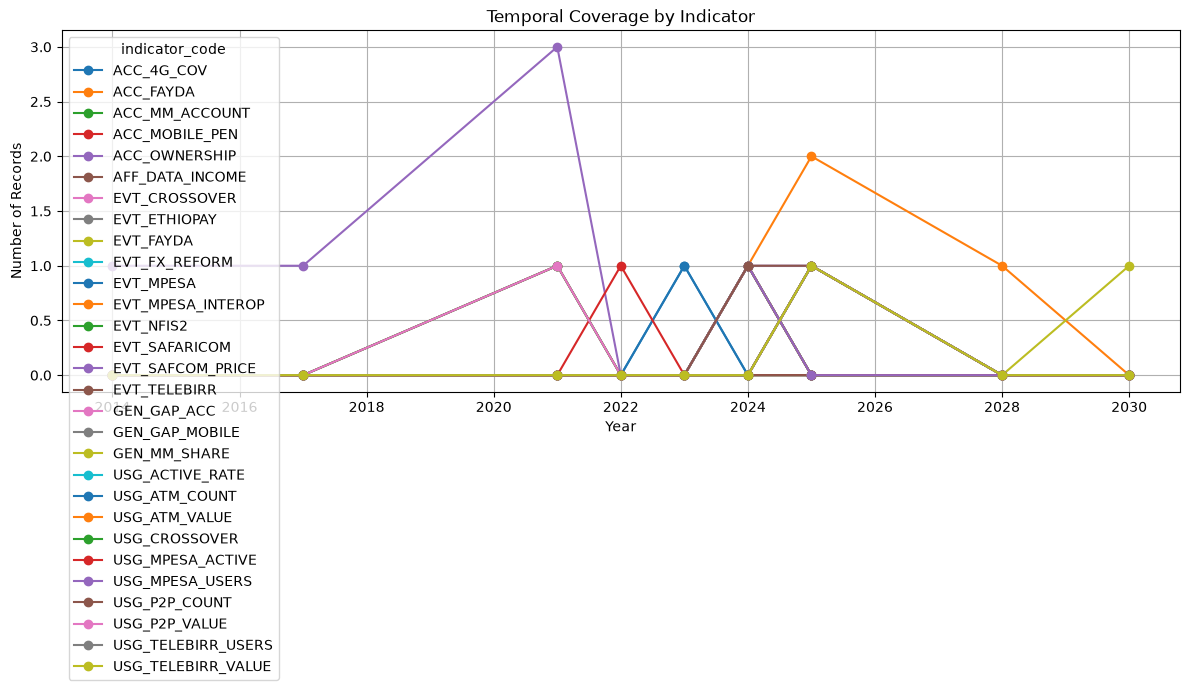

In [141]:
# Temporal coverage
plot_temporal_coverage(df)


========== CONFIDENCE DISTRIBUTION ==========
confidence
high      40
medium     3
Name: count, dtype: int64


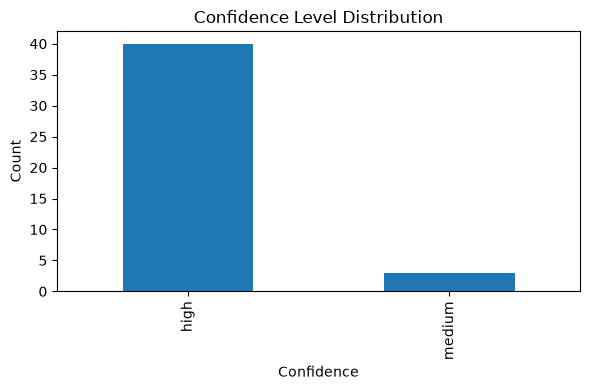

In [142]:
#  Confidence distribution
assess_confidence_levels(df)

In [143]:
# Sparse indicators
sparse = identify_sparse_indicators(df, threshold=5)


========== SPARSE INDICATORS ==========
             Indicator  Record Count
1            ACC_FAYDA             4
2       ACC_MM_ACCOUNT             2
3           ACC_4G_COV             2
4        USG_P2P_COUNT             2
5          GEN_GAP_ACC             2
6         GEN_MM_SHARE             2
7       ACC_MOBILE_PEN             1
8        USG_P2P_VALUE             1
9        USG_ATM_COUNT             1
10       USG_ATM_VALUE             1
11       USG_CROSSOVER             1
12  USG_TELEBIRR_USERS             1
13  USG_TELEBIRR_VALUE             1
14     USG_MPESA_USERS             1
15    USG_MPESA_ACTIVE             1
16     USG_ACTIVE_RATE             1
17     AFF_DATA_INCOME             1
18      GEN_GAP_MOBILE             1
19        EVT_TELEBIRR             1
20       EVT_SAFARICOM             1
21           EVT_MPESA             1
22           EVT_FAYDA             1
23       EVT_FX_REFORM             1
24       EVT_CROSSOVER             1
25   EVT_MPESA_INTEROP            

#### # Access Analysis